In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/Users/shreyadas/Desktop/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [4]:
df['director'].fillna('No Director',inplace=True)
df['cast'].fillna('No Cast',inplace=True)
df['country'].fillna('No Country',inplace=True)
df['date_added'].fillna('No Date',inplace=True)
df['rating'].fillna('No Rating',inplace=True)
df['duration'].fillna('No Duration',inplace=True)
df.isnull().sum()

/var/folders/my/dtv6m0611s17j6xqc4h6ssq40000gn/T/ipykernel_6423/1653100069.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('No Director',inplace=True)
/var/folders/my/dtv6m0611s17j6xqc4h6ssq40000gn/T/ipykernel_6423/1653100069.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alway

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

/var/folders/my/dtv6m0611s17j6xqc4h6ssq40000gn/T/ipykernel_6423/910068971.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='viridis')


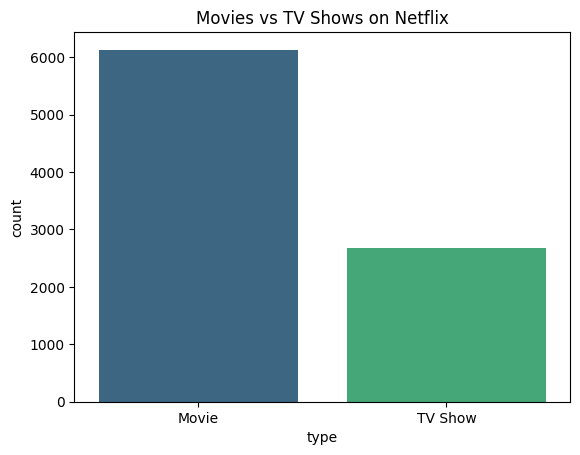

In [5]:
sns.countplot(data=df, x='type', palette='viridis')
plt.title("Movies vs TV Shows on Netflix")
plt.show()


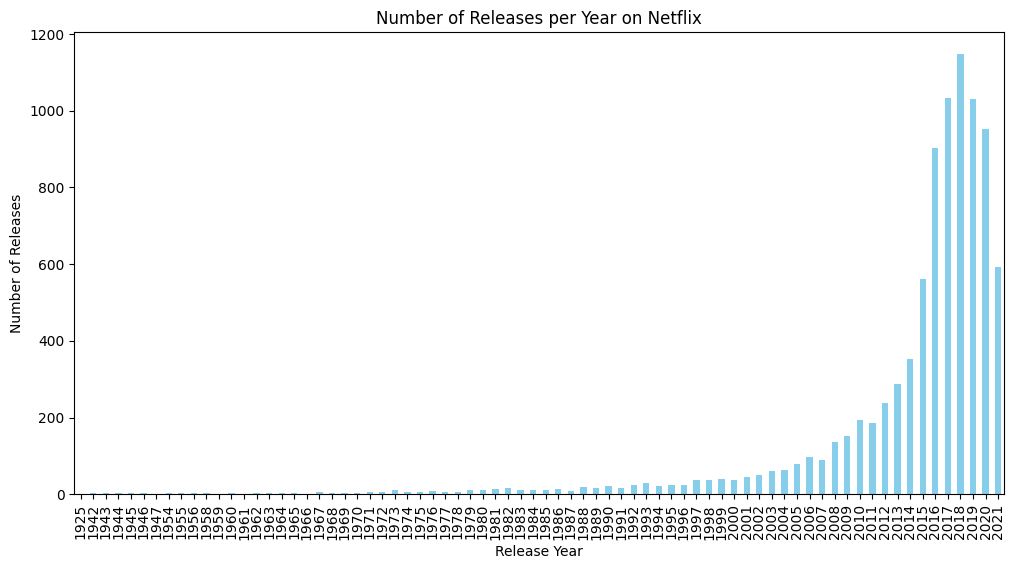

In [6]:
df['release_year'].value_counts().sort_index().plot(kind='bar', figsize=(12,6), color='skyblue')
plt.title("Number of Releases per Year on Netflix")
plt.xlabel("Release Year")
plt.ylabel("Number of Releases")
plt.show()

/var/folders/my/dtv6m0611s17j6xqc4h6ssq40000gn/T/ipykernel_6423/4174375432.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_counts.index, y=country_counts.values, palette='magma')


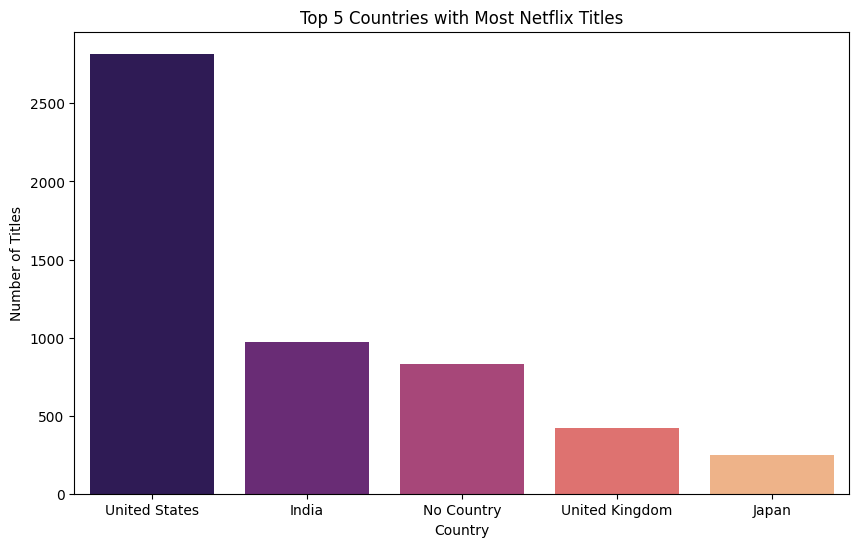

In [7]:
country_counts=df['country'].value_counts().head()
plt.figure(figsize=(10,6))
sns.barplot(x=country_counts.index, y=country_counts.values, palette='magma')
plt.title("Top 5 Countries with Most Netflix Titles")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.show()

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [9]:
df['combined'] = df['title'] + ' ' + df['director'] + ' ' + df['cast'] + ' ' + df['listed_in'] + ' ' + df['description']

In [10]:
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['combined'])
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [11]:
similarity = cosine_similarity(tfidf_matrix)


In [12]:
def recommend(title):
    # Get the index of the movie that matches the title
    indices = pd.Series(df.index, index=df['title'].str.lower())
    
    if title.lower() not in indices:
        return "❌ Title not found in dataset."
    
    idx = indices[title.lower()]
    
    # Get similarity scores
    sim_scores = list(enumerate(similarity[idx]))
    
    # Sort by similarity
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # Get top 10 similar titles
    sim_scores = sim_scores[1:11]
    
    recommended_indices = [i[0] for i in sim_scores]
    
    return df['title'].iloc[recommended_indices]


In [13]:
recommend("Breaking Bad")

2931                             Better Call Saul
3428              El Camino: A Breaking Bad Movie
8505                                     The Show
5885                               W/ Bob & David
355                            The Lincoln Lawyer
5606                             Girlfriend's Day
5352    Have You Ever Fallen in Love, Miss Jiang?
6841                                   Get Shorty
2606                              Extracurricular
5703                                  Refresh Man
Name: title, dtype: object

In [19]:
pip install streamlit

  Using cached altair-5.5.0-py3-none-any.whl.metadata (11 kB)
  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached tenacity-9.1.2-py3-none-any.whl.metadata (1.2 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached gitpython-3.1.45-py3-none-any.whl.metadata (13 kB)
  Using cached pydeck-0.9.1-py2.py3-none-any.whl.metadata (4.1 kB)
  Using cached gitdb-4.0.12-py3-none-any.whl.metadata (1.2 kB)
  Using cached smmap-5.0.2-py3-none-any.whl.metadata (4.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 3.4 MB/s  0:00:02eta 0:00:01
Using cached altair-5.5.0-py3-none-any.whl (731 kB)
Using cached blinker-1.9.0-py3-none-any.whl (8.5 kB)
Using cached gitpython-3.1.45-py3-none-any.whl (208 kB)
Using cached gitdb-4.0.12-py3-none-any.whl (62 kB)
Using cached pydeck-0.9.1-py2.py3-none-any.whl (6.9 MB)
Using cached smmap-5.0.2-py3-none-any.whl (24 kB)
Using cached tenacity-9.1.2-py3-none-any.whl (28 kB)
Using cached toml-0.10.2-py2

In [14]:
import streamlit as st



df = pd.read_csv("/Users/shreyadas/Desktop/netflix_titles.csv")
df.fillna('', inplace=True)
df['combined'] = df['title'] + ' ' + df['director'] + ' ' + df['cast'] + ' ' + df['listed_in'] + ' ' + df['description']

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['combined'])
similarity = cosine_similarity(tfidf_matrix)

st.title("🎥 Netflix Recommender System")

title = st.text_input("Enter a movie or show title:")
if title:
    indices = pd.Series(df.index, index=df['title'].str.lower())
    if title.lower() not in indices:
        st.warning("Title not found.")
    else:
        idx = indices[title.lower()]
        sim_scores = list(enumerate(similarity[idx]))
        sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:11]
        recommendations = df['title'].iloc[[i[0] for i in sim_scores]]
        st.write("**Recommended for you:**")
        st.write(recommendations.to_list())


2025-10-28 20:09:52.350 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-28 20:09:52.464 
  command:

    streamlit run /Users/shreyadas/tf-env/lib/python3.10/site-packages/ipykernel_launcher.py [ARGUMENTS]
2025-10-28 20:09:52.465 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-28 20:09:52.465 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-28 20:09:52.466 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-28 20:09:52.466 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-28 20:09:52.466 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-28 20:09:52.467 Thread 'MainT

In [15]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import pickle


In [20]:
import pickle
model_path = "//Users/shreyadas/Desktop/model.pkl"
df, cosine_sim = pickle.load(open(model_path, "rb"))
print("Model loaded successfully!", df.shape, cosine_sim.shape)


Model loaded successfully! (8807, 12) (8807, 8807)
